In [ ]:
# Cellule 0 : chargement
%run "./02_EMS_preprocessing.ipynb"

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "train": PROCESSED_DIR / "train_fuzzy_results.csv",
    "validation": PROCESSED_DIR / "validation_fuzzy_results.csv",
    "test": PROCESSED_DIR / "test_fuzzy_results.csv",
}

for path in files.values():
    if not path.exists():
        raise FileNotFoundError(f"Fichier absent : {path}")

datasets = {
    name: pd.read_csv(path)
    for name, path in files.items()
}

for name, data in datasets.items():
    print(name, data.shape)

ROOT_DIR  : C:\Users\Admin\Desktop\Projet_Artemis2
DATA_FILE : C:\Users\Admin\Desktop\Projet_Artemis2\data\Artemis.csv | existe: True
RANDOM_SEED: 42 | DEVICE: cuda
CONFIGURATION DU PROJET HESS

BATTERIE ÉNERGIE
Énergie          : 13709.89 Wh
Tension          : 450.00 V
Capacité         : 30.4664 Ah
Masse            : 55.12 kg
Courant recharge : -14.00 A
Courant décharge : 28.00 A
Configuration    : 125S7P

BATTERIE PUISSANCE
Énergie          : 2987.12 Wh
Tension          : 402.60 V
Capacité         : 7.4196 Ah
Masse            : 50.02 kg
Courant recharge : -130.00 A
Courant décharge : 400.00 A
Configuration    : 122S2P

HESS
Énergie totale   : 16697.01 Wh
Masse totale     : 105.14 kg
Tension du bus   : 402.60 V
Puissance min    : -58638.00 W
Puissance max    : 173640.00 W

MODÈLES
LSTM seul        : 7 → 64 → 3
LSTM NS          : 15 → 64 → 3
GNN simple       : 12 → 32 → 1
MLP simple       : 5 → 64 → 32 → 1
MLP NS           : 17 → 64 → 32 → 1

Device           : cuda
Fichier          : 

Paramètres de l’optimisation

In [30]:

ALPHA_GRID_STEP = 0.001

ALPHA_GRID = np.arange(
    0.0, 1.0 + ALPHA_GRID_STEP / 2.0, ALPHA_GRID_STEP, dtype=np.float64,
)

ALPHA_OPT_WEIGHTS = {
    "power_stress": 0.30,
    "energy_throughput": 0.20,
    "soc_risk": 0.25,
    "converter_stress": 0.10,
    "continuity": 0.15,
}

if not np.isclose(sum(ALPHA_OPT_WEIGHTS.values()), 1.0):
    raise ValueError("La somme des poids doit etre egale a 1.")

SOC_TOL = globals().get("SOC_TOLERANCE", 5e-4)

dt_config = globals().get("DT_SECONDS", None)

if dt_config is None or not np.isfinite(dt_config) or dt_config <= 0:
    time_values = datasets["train"][TIME_COL].to_numpy(dtype=float)
    time_differences = np.diff(time_values)
    valid_differences = time_differences[np.isfinite(time_differences) & (time_differences > 0)]
    if len(valid_differences) == 0:
        raise ValueError("Impossible de determiner le pas temporel.")
    DT_OPT_SECONDS = float(np.median(valid_differences))
else:
    DT_OPT_SECONDS = float(dt_config)

print("Nombre de candidats alpha :", len(ALPHA_GRID))
print("Poids :", ALPHA_OPT_WEIGHTS)
print("Pas temporel utilise :", DT_OPT_SECONDS, "s")

Nombre de candidats alpha : 1001
Poids : {'power_stress': 0.3, 'energy_throughput': 0.2, 'soc_risk': 0.25, 'converter_stress': 0.1, 'continuity': 0.15}
Pas temporel utilise : 1.0 s


Relation EB–convertisseur estimée sur le train


In [31]:

train_df = datasets["train"]

positive_mask = (
    (train_df["P_EB"] > EPS_POWER_W)
    & (train_df["P_conv"] > 0)
)

negative_mask = (
    (train_df["P_EB"] < -EPS_POWER_W)
    & (train_df["P_conv"] < 0)
)

CONVERTER_RATIO_DISCHARGE = float(
    np.median(
        train_df.loc[positive_mask, "P_EB"]
        / train_df.loc[positive_mask, "P_conv"]
    )
)

CONVERTER_RATIO_CHARGE = float(
    np.median(
        np.abs(
            train_df.loc[negative_mask, "P_EB"]
            / train_df.loc[negative_mask, "P_conv"]
        )
    )
)

if CONVERTER_RATIO_DISCHARGE <= 0 or CONVERTER_RATIO_CHARGE <= 0:
    raise ValueError("Rapport convertisseur non valide.")


def estimate_p_conv(p_eb):
    p_eb = np.asarray(p_eb, dtype=float)
    return np.where(
        p_eb >= 0,
        p_eb / CONVERTER_RATIO_DISCHARGE,
        p_eb / CONVERTER_RATIO_CHARGE,
    )


p_conv_train_est = estimate_p_conv(train_df["P_EB"].to_numpy())

converter_mae = float(
    np.mean(np.abs(p_conv_train_est - train_df["P_conv"].to_numpy()))
)

print("Rapport décharge :", CONVERTER_RATIO_DISCHARGE)
print("Rapport charge    :", CONVERTER_RATIO_CHARGE)
print("MAE reconstruction P_conv :", converter_mae, "W")

Rapport décharge : 9.493670886075948
Rapport charge    : 9.493670886075948
MAE reconstruction P_conv : 1.4246386787830192e-05 W


Calcul des contraintes et du coût

In [32]:

ENERGY_TOTAL_WH = ENERGY_EB_WH + ENERGY_PB_WH
ENERGY_SHARE_EB = ENERGY_EB_WH / ENERGY_TOTAL_WH
ENERGY_SHARE_PB = ENERGY_PB_WH / ENERGY_TOTAL_WH
ENERGY_COST_NORMALIZER = max(1.0 / ENERGY_SHARE_EB**2, 1.0 / ENERGY_SHARE_PB**2)


def candidate_metrics(alpha, p_dem, soc_eb, soc_pb, alpha_prev):
    alpha = np.asarray(alpha, dtype=float)
    p_pb = alpha * p_dem
    p_eb = p_dem - p_pb
    p_conv = estimate_p_conv(p_eb)
    i_eb = p_eb / V_EB_PACK_NOM
    i_pb = p_pb / V_PB_PACK_NOM
    soc_eb_next = soc_eb - i_eb * DT_OPT_SECONDS / (3600.0 * CAPACITY_EB_AH)
    soc_pb_next = soc_pb - i_pb * DT_OPT_SECONDS / (3600.0 * CAPACITY_PB_AH)

    feasible = (
        (alpha >= 0.0) & (alpha <= 1.0)
        & (p_eb >= P_EB_MIN_W) & (p_eb <= P_EB_MAX_W)
        & (p_pb >= P_PB_MIN_W) & (p_pb <= P_PB_MAX_W)
        & (p_conv >= P_CONV_MIN_W) & (p_conv <= P_CONV_MAX_W)
    )
    if soc_eb <= SOC_EB_MIN + SOC_TOL: feasible &= p_eb <= EPS_POWER_W
    if soc_pb <= SOC_PB_MIN + SOC_TOL: feasible &= p_pb <= EPS_POWER_W
    if soc_eb >= SOC_EB_MAX - SOC_TOL: feasible &= p_eb >= -EPS_POWER_W
    if soc_pb >= SOC_PB_MAX - SOC_TOL: feasible &= p_pb >= -EPS_POWER_W
    if soc_eb >= SOC_EB_MIN - SOC_TOL: feasible &= (soc_eb_next >= SOC_EB_MIN - SOC_TOL)
    if soc_pb >= SOC_PB_MIN - SOC_TOL: feasible &= (soc_pb_next >= SOC_PB_MIN - SOC_TOL)
    if soc_eb <= SOC_EB_MAX + SOC_TOL: feasible &= (soc_eb_next <= SOC_EB_MAX + SOC_TOL)
    if soc_pb <= SOC_PB_MAX + SOC_TOL: feasible &= (soc_pb_next <= SOC_PB_MAX + SOC_TOL)

    eb_directional_limit = np.where(p_eb >= 0, P_EB_MAX_W, abs(P_EB_MIN_W))
    pb_directional_limit = np.where(p_pb >= 0, P_PB_MAX_W, abs(P_PB_MIN_W))
    conv_directional_limit = np.where(p_conv >= 0, P_CONV_MAX_W, abs(P_CONV_MIN_W))
    eb_utilization = np.abs(p_eb) / eb_directional_limit
    pb_utilization = np.abs(p_pb) / pb_directional_limit
    converter_utilization = np.abs(p_conv) / conv_directional_limit
    power_stress = 0.5 * (eb_utilization**2 + pb_utilization**2)

    energy_throughput = (
        ((1.0 - alpha) / ENERGY_SHARE_EB) ** 2 + (alpha / ENERGY_SHARE_PB) ** 2
    ) / ENERGY_COST_NORMALIZER

    eb_soc_level = np.clip((soc_eb - SOC_EB_MIN) / (SOC_EB_MAX - SOC_EB_MIN), 0.0, 1.0)
    pb_soc_level = np.clip((soc_pb - SOC_PB_MIN) / (SOC_PB_MAX - SOC_PB_MIN), 0.0, 1.0)
    if p_dem > EPS_POWER_W:
        eb_soc_risk = 1.0 - eb_soc_level; pb_soc_risk = 1.0 - pb_soc_level
    elif p_dem < -EPS_POWER_W:
        eb_soc_risk = eb_soc_level; pb_soc_risk = pb_soc_level
    else:
        eb_soc_risk = 0.0; pb_soc_risk = 0.0
    soc_risk = (1.0 - alpha) * eb_soc_risk + alpha * pb_soc_risk

    converter_stress = converter_utilization**2

    if alpha_prev is not None and np.isfinite(alpha_prev):
        continuity_cost = (alpha - alpha_prev) ** 2
    else:
        continuity_cost = np.zeros_like(alpha)

    total_cost = (
        ALPHA_OPT_WEIGHTS["power_stress"] * power_stress
        + ALPHA_OPT_WEIGHTS["energy_throughput"] * energy_throughput
        + ALPHA_OPT_WEIGHTS["soc_risk"] * soc_risk
        + ALPHA_OPT_WEIGHTS["converter_stress"] * converter_stress
        + ALPHA_OPT_WEIGHTS["continuity"] * continuity_cost
    )

    return {
        "feasible": feasible, "total_cost": total_cost,
        "power_stress": power_stress, "energy_throughput": energy_throughput,
        "soc_risk": soc_risk, "converter_stress": converter_stress, "continuity_cost": continuity_cost,
        "P_EB": p_eb, "P_PB": p_pb, "P_conv": p_conv,
        "SOC_EB_next": soc_eb_next, "SOC_PB_next": soc_pb_next,
    }

Optimisation d’une observation

In [33]:
def optimize_alpha_row(p_dem, soc_eb, soc_pb, alpha_prev=None):
    if abs(p_dem) <= EPS_POWER_W:
        return {"alpha_ems_alpha_star": np.nan, "alpha_ems_alpha_star_valid": 0, "feasible_candidates": 0}

    metrics = candidate_metrics(ALPHA_GRID, p_dem, soc_eb, soc_pb, alpha_prev)
    feasible_indices = np.flatnonzero(metrics["feasible"])

    if len(feasible_indices) == 0:
        return {"alpha_ems_alpha_star": np.nan, "alpha_ems_alpha_star_valid": 0, "feasible_candidates": 0}

    feasible_costs = metrics["total_cost"][feasible_indices]
    best_index = feasible_indices[np.argmin(feasible_costs)]

    return {
        "alpha_ems_alpha_star": float(ALPHA_GRID[best_index]), "alpha_ems_alpha_star_valid": 1,
        "feasible_candidates": int(len(feasible_indices)),
        "J_star": float(metrics["total_cost"][best_index]),
        "J_power_star": float(metrics["power_stress"][best_index]),
        "J_energy_star": float(metrics["energy_throughput"][best_index]),
        "J_soc_star": float(metrics["soc_risk"][best_index]),
        "J_converter_star": float(metrics["converter_stress"][best_index]),
        "J_continuity_star": float(metrics["continuity_cost"][best_index]),
        "P_EB_ems_alpha_star": float(metrics["P_EB"][best_index]), "P_PB_ems_alpha_star": float(metrics["P_PB"][best_index]),
        "P_conv_star": float(metrics["P_conv"][best_index]),
        "SOC_EB_next_star": float(metrics["SOC_EB_next"][best_index]),
        "SOC_PB_next_star": float(metrics["SOC_PB_next"][best_index]),
    }

Test de scénarios

In [34]:

scenarios = {
    "traction normale": (5000.0, 0.70, 0.70),
    "forte traction": (30000.0, 0.80, 0.80),
    "EB faible": (5000.0, 0.22, 0.80),
    "PB faible": (5000.0, 0.80, 0.22),
    "régénération": (-10000.0, 0.60, 0.60),
    "EB presque pleine en recharge": (-8000.0, 0.98, 0.50),
    "PB presque pleine en recharge": (-8000.0, 0.50, 0.98),
}

scenario_rows = []

for name, values in scenarios.items():
    p_dem, soc_eb, soc_pb = values

    result = optimize_alpha_row(
        p_dem, soc_eb, soc_pb, alpha_prev=None,
    )

    scenario_rows.append({
        "scenario": name,
        "Pdem": p_dem,
        "SOC_EB": soc_eb,
        "SOC_PB": soc_pb,
        **result,
    })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

,scenario,Pdem,SOC_EB,SOC_PB,alpha_ems_alpha_star,alpha_ems_alpha_star_valid,feasible_candidates,J_star,J_power_star,J_energy_star,J_soc_star,J_converter_star,J_continuity_star,P_EB_ems_alpha_star,P_PB_ems_alpha_star,P_conv_star,SOC_EB_next_star,SOC_PB_next_star
0,traction normale,5000.0,0.70,0.70,0.184,1,1001,0.130570,0.052443,0.065466,0.375000,0.079940,0.0,4080.0,920.0,429.760000,0.699917,0.699914
1,forte traction,30000.0,0.80,0.80,0.863,1,421,0.239581,0.066123,0.745660,0.250000,0.081120,0.0,4110.0,25890.0,432.920000,0.799917,0.797592
2,EB faible,5000.0,0.22,0.80,0.553,1,1001,0.213740,0.015879,0.315294,0.574075,0.023988,0.0,2235.0,2765.0,235.420000,0.219955,0.799743
3,PB faible,5000.0,0.80,0.22,0.000,1,1001,0.107621,0.078735,0.047472,0.250000,0.120056,0.0,5000.0,0.0,526.666667,0.799899,0.220000
4,régénération,-10000.0,0.60,0.60,0.738,1,631,0.276691,0.096417,0.547903,0.500000,0.131858,0.0,-2620.0,-7380.0,-275.973333,0.600053,0.600686
5,EB presque pleine en recharge,-8000.0,0.98,0.50,0.778,1,788,0.268675,0.046806,0.607624,0.508200,0.060589,0.0,-1776.0,-6224.0,-187.072000,0.980036,0.500579
6,PB presque pleine en recharge,-8000.0,0.50,0.98,0.518,1,788,0.313016,0.190445,0.279353,0.685800,0.285613,0.0,-3856.0,-4144.0,-406.165333,0.500078,0.980385


Évaluation d’un alpha imposé

In [35]:

def evaluate_alpha_row(alpha, p_dem, soc_eb, soc_pb, alpha_prev=None):
    if not np.isfinite(alpha) or abs(p_dem) <= EPS_POWER_W:
        return {"feasible": 0, "cost": np.nan}

    metrics = candidate_metrics(np.array([alpha]), p_dem, soc_eb, soc_pb, alpha_prev)
    return {"feasible": int(metrics["feasible"][0]), "cost": float(metrics["total_cost"][0])}

Optimisation d’un split

In [36]:

def optimize_dataset(data):
    output = data.copy()
    n = len(output)

    alpha_star = np.full(n, np.nan)
    alpha_valid = np.zeros(n, dtype=np.int8)
    feasible_count = np.zeros(n, dtype=np.int32)
    j_star = np.full(n, np.nan); j_power = np.full(n, np.nan); j_energy = np.full(n, np.nan)
    j_soc = np.full(n, np.nan); j_converter = np.full(n, np.nan); j_continuity = np.full(n, np.nan)
    p_eb_star = np.full(n, np.nan); p_pb_star = np.full(n, np.nan); p_conv_star = np.full(n, np.nan)
    soc_eb_next = np.full(n, np.nan); soc_pb_next = np.full(n, np.nan)
    fuzzy_feasible = np.zeros(n, dtype=np.int8); priority_feasible = np.zeros(n, dtype=np.int8)
    fuzzy_cost = np.full(n, np.nan); priority_cost = np.full(n, np.nan)

    p_values = output["hasPower"].to_numpy()
    soc_eb_values = output["SOC_EB"].to_numpy()
    soc_pb_values = output["SOC_PB"].to_numpy()
    fuzzy_values = output["alpha_ems_fuzzy_logic"].to_numpy()
    priority_values = output["alpha_ems_eb_priority"].to_numpy()

    alpha_star_prev = None
    fuzzy_prev = None
    priority_prev = None

    for index in range(n):
        p_dem, soc_eb, soc_pb = p_values[index], soc_eb_values[index], soc_pb_values[index]

        result = optimize_alpha_row(p_dem, soc_eb, soc_pb, alpha_star_prev)
        alpha_star[index] = result.get("alpha_ems_alpha_star", np.nan)
        alpha_valid[index] = result.get("alpha_ems_alpha_star_valid", 0)
        feasible_count[index] = result.get("feasible_candidates", 0)

        if alpha_valid[index]:
            j_star[index] = result["J_star"]; j_power[index] = result["J_power_star"]
            j_energy[index] = result["J_energy_star"]; j_soc[index] = result["J_soc_star"]
            j_converter[index] = result["J_converter_star"]; j_continuity[index] = result["J_continuity_star"]
            p_eb_star[index] = result["P_EB_ems_alpha_star"]; p_pb_star[index] = result["P_PB_ems_alpha_star"]
            p_conv_star[index] = result["P_conv_star"]
            soc_eb_next[index] = result["SOC_EB_next_star"]; soc_pb_next[index] = result["SOC_PB_next_star"]
            alpha_star_prev = alpha_star[index]

        fuzzy_eval = evaluate_alpha_row(fuzzy_values[index], p_dem, soc_eb, soc_pb, fuzzy_prev)
        priority_eval = evaluate_alpha_row(priority_values[index], p_dem, soc_eb, soc_pb, priority_prev)

        fuzzy_feasible[index] = fuzzy_eval["feasible"]
        priority_feasible[index] = priority_eval["feasible"]
        fuzzy_cost[index] = fuzzy_eval["cost"]
        priority_cost[index] = priority_eval["cost"]

        if np.isfinite(fuzzy_values[index]): fuzzy_prev = fuzzy_values[index]
        if np.isfinite(priority_values[index]): priority_prev = priority_values[index]

    output["alpha_ems_alpha_star"] = alpha_star
    output["alpha_ems_alpha_star_valid"] = alpha_valid
    output["alpha_star_feasible_candidates"] = feasible_count
    output["J_star"] = j_star; output["J_power_star"] = j_power; output["J_energy_star"] = j_energy
    output["J_soc_star"] = j_soc; output["J_converter_star"] = j_converter; output["J_continuity_star"] = j_continuity
    output["P_EB_ems_alpha_star"] = p_eb_star; output["P_PB_ems_alpha_star"] = p_pb_star; output["P_conv_star"] = p_conv_star
    output["SOC_EB_next_star"] = soc_eb_next; output["SOC_PB_next_star"] = soc_pb_next
    output["fuzzy_feasible"] = fuzzy_feasible; output["priority_feasible"] = priority_feasible
    output["J_fuzzy"] = fuzzy_cost; output["J_priority"] = priority_cost

    return output

Exécution et sauvegarde

In [37]:
# Cellule 16
optimized_datasets = {}

for split_name, data in datasets.items():
    print("Optimisation :", split_name)

    optimized = optimize_dataset(data)

    optimized_datasets[split_name] = optimized

    output_file = (
        PROCESSED_DIR
        / f"{split_name}_alpha_star.csv"
    )

    optimized.to_csv(output_file, index=False)

    print(
        "alpha* valides :",
        int(optimized["alpha_ems_alpha_star_valid"].sum()),
        "/",
        len(optimized),
    )

    print("Fichier :", output_file)

Optimisation : train
alpha* valides : 5851 / 7265
Fichier : C:\Users\Admin\Desktop\Projet_Artemis2\data\processed\train_alpha_star.csv
Optimisation : validation
alpha* valides : 3113 / 3632
Fichier : C:\Users\Admin\Desktop\Projet_Artemis2\data\processed\validation_alpha_star.csv
Optimisation : test
alpha* valides : 3066 / 3633
Fichier : C:\Users\Admin\Desktop\Projet_Artemis2\data\processed\test_alpha_star.csv


Contrôles physiques

In [38]:
control_rows = []

for split_name, data in optimized_datasets.items():
    valid_star = (
        data["alpha_ems_alpha_star_valid"] == 1
    )

    no_feasible = (
        (
            data["hasPower"].abs()
            > EPS_POWER_W
        )
        & ~valid_star
    )

    balance_error = (
        data.loc[
            valid_star,
            "hasPower",
        ]
        - data.loc[
            valid_star,
            "P_EB_ems_alpha_star",
        ]
        - data.loc[
            valid_star,
            "P_PB_ems_alpha_star",
        ]
    )

    control_rows.append({
        "split": split_name,
        "valid_alpha_star": int(
            valid_star.sum()
        ),
        "no_feasible_solution": int(
            no_feasible.sum()
        ),
        "max_power_balance_error_W": float(
            balance_error.abs().max()
        ),
        "alpha_star_min": float(
            data.loc[
                valid_star,
                "alpha_ems_alpha_star",
            ].min()
        ),
        "alpha_star_max": float(
            data.loc[
                valid_star,
                "alpha_ems_alpha_star",
            ].max()
        ),
        "alpha_star_mean": float(
            data.loc[
                valid_star,
                "alpha_ems_alpha_star",
            ].mean()
        ),
    })

control_df = pd.DataFrame(
    control_rows
)

display(control_df)

control_df.to_csv(
    TABLES_DIR
    / "alpha_star_controls.csv",
    index=False,
)

,split,valid_alpha_star,no_feasible_solution,max_power_balance_error_W,alpha_star_min,alpha_star_max,alpha_star_mean
0,train,5851,73,4.547474e-13,0.0,0.974,0.394443
1,validation,3113,0,4.547474e-13,0.0,0.972,0.449678
2,test,3066,0,4.547474e-13,0.0,0.998,0.528255


Comparaison des stratégies

In [39]:
# Cellule 18
control_rows = []

for split_name, data in optimized_datasets.items():
    valid_star = (data["alpha_ems_alpha_star_valid"] == 1)

    no_feasible = (
        (data["hasPower"].abs() > EPS_POWER_W)
        & ~valid_star
    )

    balance_error = (
        data.loc[valid_star, "hasPower"]
        - data.loc[valid_star, "P_EB_ems_alpha_star"]
        - data.loc[valid_star, "P_PB_ems_alpha_star"]
    )

    control_rows.append({
        "split": split_name,
        "valid_alpha_star": int(valid_star.sum()),
        "no_feasible_solution": int(no_feasible.sum()),
        "max_power_balance_error_W": float(balance_error.abs().max()),
        "alpha_star_min": float(data.loc[valid_star, "alpha_ems_alpha_star"].min()),
        "alpha_star_max": float(data.loc[valid_star, "alpha_ems_alpha_star"].max()),
        "alpha_star_mean": float(data.loc[valid_star, "alpha_ems_alpha_star"].mean()),
    })

control_df = pd.DataFrame(control_rows)
display(control_df)

control_df.to_csv(TABLES_DIR / "alpha_star_controls.csv", index=False)

,split,valid_alpha_star,no_feasible_solution,max_power_balance_error_W,alpha_star_min,alpha_star_max,alpha_star_mean
0,train,5851,73,4.547474e-13,0.0,0.974,0.394443
1,validation,3113,0,4.547474e-13,0.0,0.972,0.449678
2,test,3066,0,4.547474e-13,0.0,0.998,0.528255


 Comparaison sur le test

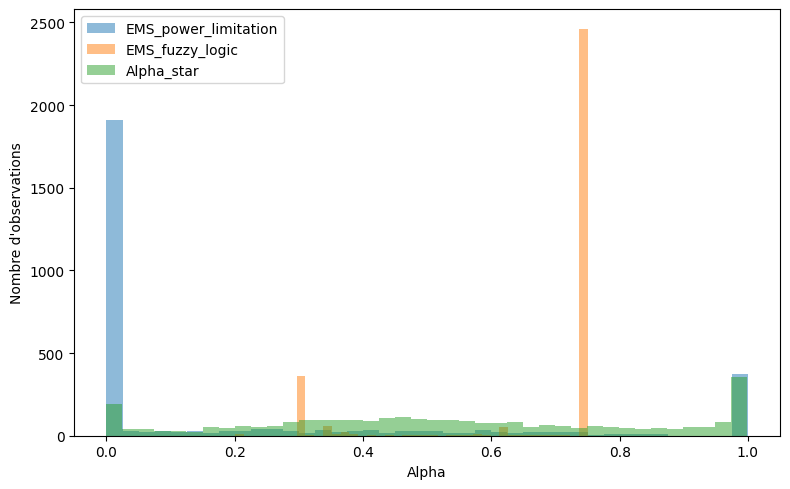

In [47]:
# Cellule 22
test_opt = optimized_datasets["test"]

valid_plot = (
    test_opt["alpha_ems_alpha_star_valid"].eq(1)
    & test_opt["alpha_ems_eb_priority"].notna()
)

plt.figure(figsize=(8, 5))
plt.hist(test_opt.loc[valid_plot, "alpha_ems_eb_priority"], bins=40, alpha=0.5, label="EMS_power_limitation")
plt.hist(test_opt.loc[valid_plot, "alpha_ems_fuzzy_logic"], bins=40, alpha=0.5, label="EMS_fuzzy_logic")
plt.hist(test_opt.loc[valid_plot, "alpha_ems_alpha_star"], bins=40, alpha=0.5, label="Alpha_star")
plt.xlabel("Alpha")
plt.ylabel("Nombre d'observations")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "alpha_strategy_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


Sauvegarde de la définition du coût


In [48]:
# Cellule 24
cost_definition = {
    "alpha_grid_step": ALPHA_GRID_STEP,
    "weights": ALPHA_OPT_WEIGHTS,
    "converter_ratio_discharge": CONVERTER_RATIO_DISCHARGE,
    "converter_ratio_charge": CONVERTER_RATIO_CHARGE,
    "soc_tolerance": SOC_TOL,
    "dt_seconds": DT_OPT_SECONDS,
    "description": (
        "Alpha-star minimizes a surrogate physical cost "
        "(power stress, energy throughput, SOC risk, converter stress, continuity) "
        "under hard constraints."
    ),
}

cost_file = MODELS_DIR / "alpha_star_cost_definition.json"

with open(cost_file, "w", encoding="utf-8") as file:
    json.dump(cost_definition, file, indent=2)

print("Définition du coût :", cost_file)

Définition du coût : C:\Users\Admin\Desktop\Projet_Artemis2\models\alpha_star_cost_definition.json


In [42]:

train_opt = optimized_datasets["train"]

infeasible_train = train_opt[
    (train_opt["hasPower"].abs() > EPS_POWER_W)
    & (train_opt["alpha_ems_alpha_star_valid"] == 0)
].copy()

infeasible_train["regeneration"] = (infeasible_train["hasPower"] < -EPS_POWER_W)
infeasible_train["traction"] = (infeasible_train["hasPower"] > EPS_POWER_W)
infeasible_train["EB_near_full"] = (infeasible_train["SOC_EB"] >= SOC_EB_MAX - SOC_TOL)
infeasible_train["PB_near_full"] = (infeasible_train["SOC_PB"] >= SOC_PB_MAX - SOC_TOL)
infeasible_train["EB_near_min"] = (infeasible_train["SOC_EB"] <= SOC_EB_MIN + SOC_TOL)
infeasible_train["PB_near_min"] = (infeasible_train["SOC_PB"] <= SOC_PB_MIN + SOC_TOL)

diagnostic = pd.DataFrame([{
    "total": len(infeasible_train),
    "regeneration": int(infeasible_train["regeneration"].sum()),
    "traction": int(infeasible_train["traction"].sum()),
    "EB_near_full": int(infeasible_train["EB_near_full"].sum()),
    "PB_near_full": int(infeasible_train["PB_near_full"].sum()),
    "both_near_full": int((infeasible_train["EB_near_full"] & infeasible_train["PB_near_full"]).sum()),
    "both_near_min": int((infeasible_train["EB_near_min"] & infeasible_train["PB_near_min"]).sum()),
}])

display(diagnostic)
display(infeasible_train[[TIME_COL, "hasPower", "SOC_EB", "SOC_PB", "P_EB", "P_PB", "P_conv"]].describe())

,total,regeneration,traction,EB_near_full,PB_near_full,both_near_full,both_near_min
0,73,73,0,0,71,0,0


,time,hasPower,SOC_EB,SOC_PB,P_EB,P_PB,P_conv
count,73.000000,73.000000,73.000000,73.000000,73.0,73.000000,73.0
mean,643.547945,-14081.397945,0.982196,0.999922,-6300.0,-7781.397945,-663.6
std,290.987020,7884.372658,0.007608,0.000244,0.0,7884.372658,0.0
min,57.000000,-43566.270000,0.970517,0.998290,-6300.0,-37266.270000,-663.6
25%,430.000000,-16846.160000,0.977300,1.000000,-6300.0,-10546.160000,-663.6
50%,639.000000,-11404.050000,0.980890,1.000000,-6300.0,-5104.050000,-663.6
75%,908.000000,-8489.920000,0.986673,1.000000,-6300.0,-2189.920000,-663.6
max,1086.000000,-6539.870000,0.998002,1.000000,-6300.0,-239.870000,-663.6


In [49]:

infeasible_train["P_regen_absorbable"] = P_EB_MIN_W

infeasible_train["P_regen_curtailed"] = np.minimum(
    0.0,
    infeasible_train["hasPower"] - infeasible_train["P_regen_absorbable"],
)

display(infeasible_train[[TIME_COL, "hasPower", "P_regen_absorbable", "P_regen_curtailed", "SOC_EB", "SOC_PB"]].head())

,time,hasPower,P_regen_absorbable,P_regen_curtailed,SOC_EB,SOC_PB
56,57,-13398.42,-6300.0,-7098.42,0.997746,0.999804
57,58,-7541.50,-6300.0,-1241.50,0.997874,1.000000
58,59,-9575.29,-6300.0,-3275.29,0.998002,1.000000
128,129,-13398.42,-6300.0,-7098.42,0.996123,0.999804
129,130,-7541.50,-6300.0,-1241.50,0.996250,1.000000


In [44]:
# Cellule 27
dt = DT_OPT_SECONDS

eb_soc_charge_limit = -(
    (SOC_EB_MAX - infeasible_train["SOC_EB"]).clip(lower=0.0)
    * 3600.0 * CAPACITY_EB_AH * V_EB_PACK_NOM / dt
)

pb_soc_charge_limit = -(
    (SOC_PB_MAX - infeasible_train["SOC_PB"]).clip(lower=0.0)
    * 3600.0 * CAPACITY_PB_AH * V_PB_PACK_NOM / dt
)

infeasible_train["P_EB_charge_limit"] = np.maximum(P_EB_MIN_W, eb_soc_charge_limit)
infeasible_train["P_PB_charge_limit"] = np.maximum(P_PB_MIN_W, pb_soc_charge_limit)

infeasible_train["P_regen_absorbable_min"] = (
    infeasible_train["P_EB_charge_limit"] + infeasible_train["P_PB_charge_limit"]
)

infeasible_train["P_regen_absorbed"] = np.maximum(
    infeasible_train["hasPower"], infeasible_train["P_regen_absorbable_min"],
)

infeasible_train["P_regen_curtailed_signed"] = (
    infeasible_train["hasPower"] - infeasible_train["P_regen_absorbed"]
)

infeasible_train["P_regen_curtailed_abs"] = (
    -infeasible_train["P_regen_curtailed_signed"]
).clip(lower=0.0)

infeasible_train["P_mechanical_braking_W"] = infeasible_train["P_regen_curtailed_abs"]

In [45]:
# Cellule 28
display(infeasible_train[[
    TIME_COL, "hasPower", "SOC_EB", "SOC_PB",
    "P_EB_charge_limit", "P_PB_charge_limit", "P_regen_absorbable_min",
    "P_regen_absorbed", "P_regen_curtailed_signed", "P_regen_curtailed_abs",
]].head())

,time,hasPower,SOC_EB,SOC_PB,P_EB_charge_limit,P_PB_charge_limit,P_regen_absorbable_min,P_regen_absorbed,P_regen_curtailed_signed,P_regen_curtailed_abs
56,57,-13398.42,0.997746,0.999804,-6300.0,-2107.711872,-8407.711872,-8407.711872,-4990.708128,4990.708128
57,58,-7541.50,0.997874,1.000000,-6300.0,-0.000000,-6300.000000,-6300.000000,-1241.500000,1241.500000
58,59,-9575.29,0.998002,1.000000,-6300.0,-0.000000,-6300.000000,-6300.000000,-3275.290000,3275.290000
128,129,-13398.42,0.996123,0.999804,-6300.0,-2107.711872,-8407.711872,-8407.711872,-4990.708128,4990.708128
129,130,-7541.50,0.996250,1.000000,-6300.0,-0.000000,-6300.000000,-6300.000000,-1241.500000,1241.500000


In [46]:
# Cellule 29
power_balance_tolerance_w = float(globals().get("POWER_BALANCE_TOLERANCE_W", 1e-6))

if not np.isfinite(power_balance_tolerance_w) or power_balance_tolerance_w <= 0:
    raise ValueError("La tolérance du bilan de puissance doit être positive.")

balance_error = (
    infeasible_train["hasPower"]
    - infeasible_train["P_regen_absorbed"]
    - infeasible_train["P_regen_curtailed_signed"]
)

if (infeasible_train["P_regen_curtailed_abs"] < 0).any():
    raise ValueError("Une puissance non récupérable négative a été détectée.")

real_infeasible = (infeasible_train["P_regen_curtailed_abs"] > power_balance_tolerance_w)

print("Tolérance du bilan :", power_balance_tolerance_w, "W")
print("Erreur maximale de bilan :", float(balance_error.abs().max()), "W")
print("Cas réellement non absorbables :", int(real_infeasible.sum()), "/", len(infeasible_train))
print("Puissance totale non récupérée :", float(infeasible_train.loc[real_infeasible, "P_regen_curtailed_abs"].sum()), "W·échantillon")
print("Puissance moyenne non récupérée :", float(infeasible_train.loc[real_infeasible, "P_regen_curtailed_abs"].mean()), "W")

Tolérance du bilan : 1e-06 W
Erreur maximale de bilan : 0.0 W
Cas réellement non absorbables : 73 / 73
Puissance totale non récupérée : 506757.1012320022 W·échantillon
Puissance moyenne non récupérée : 6941.878099068524 W
